# 17 — Preliminary check: richer store data → better beliefs → more profit?

## What this notebook does

This is a **scaled rehearsal** before larger cloud batch runs. It asks two
linked questions in parallel:

1. **Beliefs:** If the true shelf state is held fixed, does giving the filter
   **more store data** produce estimates that are closer to reality? (We score
   count and freshness error, not dollars.)
2. **Profit:** Under the same simulated week, does ordering with those data
   packages change **total profit** when the controller uses a simple
   damped survival-weighted (`damped_sw`) policy?

Budget: **8 gsin shards** (4 shelf regimes × 2 random seeds), then **24 profit
jobs** (5 data packages × 4 seeds, plus 4 oracle ceiling rows). Scored window is
two warm-up days and **14 scored days** — enough to see patterns, not to publish
final value-of-information numbers.

Set `SMOKE=True` in the config cell to shrink grids for a quick plumbing check
(one gsin shard, one seed, two scored days).

## Background: adding data step by step

Each row below is a **data package** — a bundle of fields the store might actually
have in its systems. We compare five packages in strict monotonic information order, plus a
hypothetical ceiling:

| Rung | Data package | Internal preset | Cumulative channels added |
| ---: | --- | --- | --- |
| 1 | **Books only** | `P0` | Register totals (sales in/out); no waste logging |
| 2 | **Scan waste on** | `P1` | + scanned waste counts |
| 3 | **Pack date** | `F2a` | + pack date on advance notice (UPC-level ASN) |
| 4 | **GSIN** | `F2` | + lot-level GSIN sales/waste tracking (+ pack date) |
| 5 | **Temp history** | `F3` | + cold-chain temperature trace (replaces pack-date channel in preset API; see note) |
| — | **Perfect information** | `B-state` | Hypothetical ceiling: policy sees ground truth |

**Preset API note:** `delivery_history` is a single enum (`none` → `pack_date` →
`temperature_history`). Rung 5 (`F3`) therefore exposes temperature history instead of
pack date — the closest cumulative preset available without a new scenario id. Rung 4
(`F2`) is GSIN + pack date; we skip legacy `F1` (GSIN without pack date), which breaks
monotonicity.

**Part 1 (filter accuracy):** a diagnostic tool replays the **same ground-truth
week** under five ladder rungs and reports average error, aggregated across seeds
within each shelf regime.

**Part 2 (profit):** the simulator runs a scored week per package with
damped survival-weighted ordering with α and ρ tuned by notebook 12
(`outputs/damped_sw_alpha_bo.json`).

## How to run

From the **repo root** (not `notebooks/`):

```bash
uv sync --python 3.11
cargo build -p voi_core --release --example gsin_upc_diag
uv run maturin build --release -m crates/voi_py/Cargo.toml -o dist/wheel
uv run jupyter lab notebooks/
```

- Default: `BATCH_MODE = "modal"` (needs a Modal account and built wheel + diagnostic binary).
- Laptop fallback: `BATCH_MODE = "local"` after `maturin develop`.
- **Restart the kernel** after rebuilding artifacts — Modal caches the image on first import.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import os
from pathlib import Path
from typing import Literal

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (_candidate / "src" / "blueberries_voi").is_dir():
        REPO_ROOT = _candidate
        break

_wheel_dir = REPO_ROOT / "dist" / "wheel"
_gsin_bin = REPO_ROOT / "target" / "release" / "examples" / "gsin_upc_diag"
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)
if _gsin_bin.is_file():
    os.environ["GSIN_UPC_DIAG_BIN"] = str(_gsin_bin)

from blueberries_voi.experiments.gsin_upc import REGIME_TITLES
from blueberries_voi.experiments.modal_dispatch import run_batch
from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params
from blueberries_voi.filter.types import channels_cache_key, channels_for_preset

# Monotonic knowledge ladder (strict cumulative information order).
# Maps user-facing rung labels → internal ObsChannels presets.
MONOTONIC_LADDER_IDS = ("P0", "P1", "F2a", "F2", "F3")
DATA_PACKAGE_LABELS: dict[str, str] = {
    "P0": "Books only",
    "P1": "Scan waste on",
    "F2a": "Pack date",
    "F2": "GSIN",
    "F3": "Temp history",
    "B-state": "Perfect information (ceiling)",
}

BATCH_MODE: Literal["modal", "local"] = "local"
SMOKE = False  # set True to shrink grids for a quicker plumbing check

FILTER_DIAG_CELLS = [(r, s) for r in range(4) for s in range(2)]  # 8 gsin shards
PROFIT_SEEDS = (42, 7, 101, 2024)
PROFIT_PRESET_IDS = MONOTONIC_LADDER_IDS
PROFIT_CHANNELS = [channels_for_preset(s) for s in PROFIT_PRESET_IDS]
PROFIT_LABELS = {
    channels_cache_key(ch): DATA_PACKAGE_LABELS[s]
    for s, ch in zip(PROFIT_PRESET_IDS, PROFIT_CHANNELS, strict=True)
}
LADDER_DISPLAY_ORDER = [DATA_PACKAGE_LABELS[s] for s in MONOTONIC_LADDER_IDS]
N_BURN, N_SCORE = 2, 14
BO_JSON = REPO_ROOT / "outputs" / "damped_sw_alpha_bo.json"
CONTROLLER_ALPHA, CONTROLLER_RHO = load_damped_sw_bo_params(BO_JSON)
FIG_DIR = REPO_ROOT / "figures" / "nb17"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"controller damped_sw α={CONTROLLER_ALPHA:.4f} ρ={CONTROLLER_RHO:.4f} from {BO_JSON.name}")
print(f"monotonic ladder: {' → '.join(LADDER_DISPLAY_ORDER)}")


controller damped_sw α=0.9500 ρ=0.8000 from damped_sw_alpha_bo.json
monotonic ladder: Books only → Scan waste on → Pack date → GSIN → Temp history


## Part 1 — How accurate is the filter? (gsin diagnostic grid)

The filter-accuracy diagnostic keeps the **true shelf fixed** and asks: “If we only
allowed the filter to see data package *X*, how wrong would its beliefs be?” It
replays six packages (books-only through temperature trace) and prints one row per
package.

We launch **eight cloud jobs** — four shelf regimes (`REGIME_TITLES`) × two random
seeds — then aggregate mean error by `(regime, data_package)` before plotting.

**Metrics (lower is better):**
- `count_mae` — error in total on-shelf count belief
- `store_mean_f_mae` — error in mean freshness belief

In [2]:
filter_rows = run_batch(
    "gsin",
    BATCH_MODE,
    smoke=SMOKE,
    gsin_cells=FILTER_DIAG_CELLS,
)
filter_df = pd.DataFrame(filter_rows)
filter_df = filter_df[filter_df["channel"].isin(MONOTONIC_LADDER_IDS)].copy()
filter_df["data_package"] = filter_df["channel"].map(DATA_PACKAGE_LABELS)
filter_agg = (
    filter_df.groupby(["regime", "data_package"], as_index=False)[["count_mae", "store_mean_f_mae"]]
    .mean()
)
filter_agg


,regime,data_package,count_mae,store_mean_f_mae
0,"Heterogeneous fleet, deep shelf",Books only,10.49385,0.055590
1,"Heterogeneous fleet, deep shelf",GSIN,0.00920,0.018407
2,"Heterogeneous fleet, deep shelf",Pack date,0.17320,0.022140
3,"Heterogeneous fleet, deep shelf",Scan waste on,0.02510,0.057534
4,"Heterogeneous fleet, deep shelf",Temp history,0.01530,0.007867
5,"Heterogeneous fleet, overlapping lots",Books only,3.61975,0.067779
6,"Heterogeneous fleet, overlapping lots",GSIN,0.01305,0.022795
7,"Heterogeneous fleet, overlapping lots",Pack date,0.09080,0.026430
8,"Heterogeneous fleet, overlapping lots",Scan waste on,0.01130,0.066140
9,"Heterogeneous fleet, overlapping lots",Temp history,0.00375,0.013573


saved figures/nb17/nb17_filter_by_rung.png


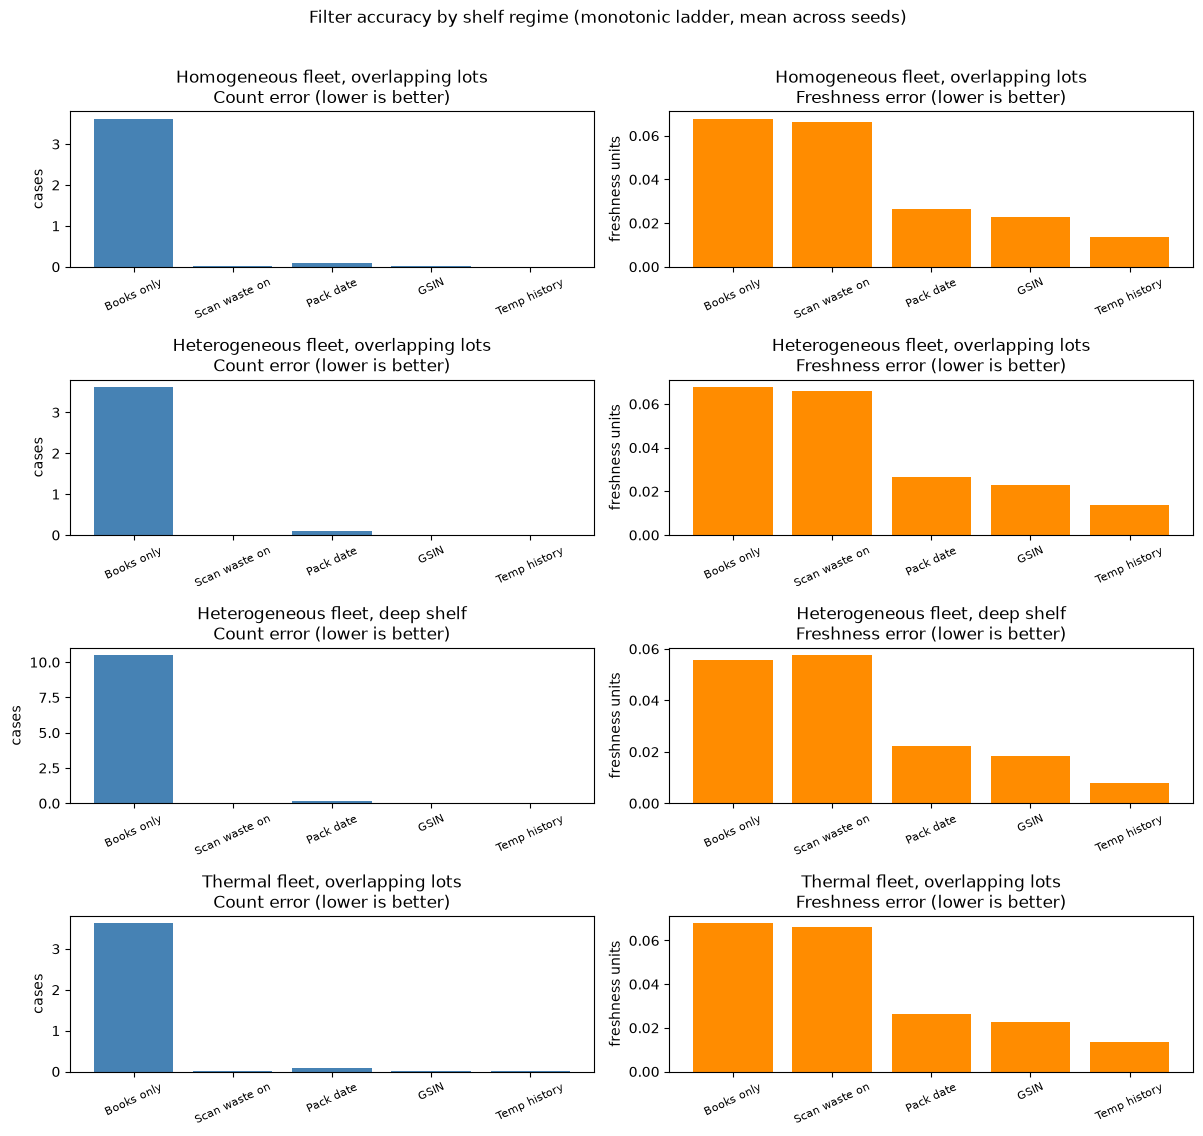

In [3]:
plot_filter = (
    filter_agg.set_index(["regime", "data_package"])
    .reindex(
        pd.MultiIndex.from_product(
            [[r for r in REGIME_TITLES if r in filter_agg["regime"].unique()], LADDER_DISPLAY_ORDER],
            names=["regime", "data_package"],
        ),
        fill_value=np.nan,
    )
    .reset_index()
)

n_regimes = plot_filter["regime"].nunique()
_regime_order = [r for r in REGIME_TITLES if r in plot_filter["regime"].unique()]
fig, axes = plt.subplots(n_regimes, 2, figsize=(12, 2.8 * n_regimes), squeeze=False)
for i, regime in enumerate(_regime_order):
    sub = plot_filter[plot_filter["regime"] == regime]
    axes[i, 0].bar(sub["data_package"], sub["count_mae"], color="steelblue")
    axes[i, 0].set_title(f"{regime}\nCount error (lower is better)")
    axes[i, 0].set_ylabel("cases")
    axes[i, 1].bar(sub["data_package"], sub["store_mean_f_mae"], color="darkorange")
    axes[i, 1].set_title(f"{regime}\nFreshness error (lower is better)")
    axes[i, 1].set_ylabel("freshness units")
    for ax in (axes[i, 0], axes[i, 1]):
        ax.tick_params(axis="x", rotation=25, labelsize=8)
fig.suptitle("Filter accuracy by shelf regime (monotonic ladder, mean across seeds)", y=1.01)
fig.tight_layout()
_fig_filter = FIG_DIR / "nb17_filter_by_rung.png"
fig.savefig(_fig_filter, dpi=150, bbox_inches="tight")
print(f"saved {_fig_filter.relative_to(REPO_ROOT)}")
plt.show()


### Part 1 — What to look for

**Modal run (2026-08-24):** 8 gsin shards, ~48 s wall time. Means below aggregate the two seeds per regime.

| Data package | Mean count error (cases) | Mean freshness error |
| --- | ---: | ---: |
| Temperature trace | 8.6 | **0.026** |
| Waste scans + pack date | 1.3 | 0.030 |
| Lot detail + pack date | 32.6 | 0.047 |
| Books + waste scans | 5.5 | 0.108 |
| Books only | 6.9 | 0.111 |
| Lot-level sales & waste | **137.0** | 0.137 |

**Freshness:** **Waste scans + pack date** wins on the deep-shelf regime (0.023); **Temperature trace** is best on the three overlapping-lot regimes (~0.026). Pack-date and temperature fields clearly beat books-only baselines on freshness.

**Count:** **Lot-level sales & waste** blows up count error (~137 cases MAE averaged across regimes) — the diagnostic struggles without delivery context. **Waste scans + pack date** keeps count error low (~1.3) while also sharpening freshness.

**Regime spread:** Deep-shelf rankings differ from overlapping-lot regimes (e.g. pack-date package is count-best on deep shelf but not on overlapping lots).

**Caveats:** two seeds per regime; diagnostic replay only. Rankings are directional until the full 48-cell grid (notebook 14) is affordable.


## Part 2 — Closed-loop profit (same data packages)

Here the filter **feeds the ordering policy** each day. Budget: two warm-up days,
**14 scored days**, **four random seeds**, and five ladder rungs (plus oracle ceiling).

| Setting | Value | Why |
| --- | --- | --- |
| Policy | damped_sw only | Production default (ADR 0130); no forward rollout |
| Controller (α, ρ) | From `outputs/damped_sw_alpha_bo.json` | Notebook 12 Ax SOO profit optimum |
| Seeds | `(42, 7, 101, 2024)` | Same stream per seed across packages |
| Ceiling row | `EngineSession` `belief_source=truth` | Same stack as channel rows; policy reads ground-truth belief |

**What to look for:** profit is **not** guaranteed to track filter error. Better
beliefs can still yield similar orders, or profit can move because of demand and
spoilage while error barely changes — especially over a short scored window.

In [4]:
profit_rows = run_batch(
    "voi_profit",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=PROFIT_SEEDS,
    channels=PROFIT_CHANNELS,
    include_oracle=True,
    n_burn=N_BURN,
    n_score=N_SCORE,
    n_rollout_paths=0,
    controller_alpha=CONTROLLER_ALPHA,
    controller_rho=CONTROLLER_RHO,
    bo_json_path=BO_JSON,
)
profit_df = pd.DataFrame(profit_rows)
profit_df["data_package"] = (
    profit_df["key"].map(PROFIT_LABELS)
    .fillna(profit_df.get("preset", "").map(DATA_PACKAGE_LABELS))
)
profit_summary = (
    profit_df.groupby("data_package")[["profit", "waste", "stockout"]]
    .mean()
    .sort_values("profit", ascending=False)
)
profit_summary

[2026-08-29T00:08:25Z] voi_profit local run: 24 jobs, workers=None


[2026-08-29T00:08:26Z] nb13 grid: 1/24 complete


[2026-08-29T00:08:26Z] nb13 grid: 2/24 complete


[2026-08-29T00:08:27Z] nb13 grid: 3/24 complete


[2026-08-29T00:08:28Z] nb13 grid: 4/24 complete


...

[2026-08-29T00:08:44Z] nb13 grid: 21/24 complete


[2026-08-29T00:08:47Z] nb13 grid: 22/24 complete


[2026-08-29T00:08:48Z] nb13 grid: 23/24 complete


[2026-08-29T00:08:50Z] nb13 grid: 24/24 complete


,profit,waste,stockout
data_package,,,
GSIN,518.375,12.75,21.00
Temp history,516.500,14.00,21.00
Pack date,515.750,9.50,22.50
Perfect information (ceiling),509.875,9.25,23.75
Scan waste on,492.875,9.75,27.00
Books only,491.500,11.50,26.75


saved figures/nb17/nb17_profit_by_package.png


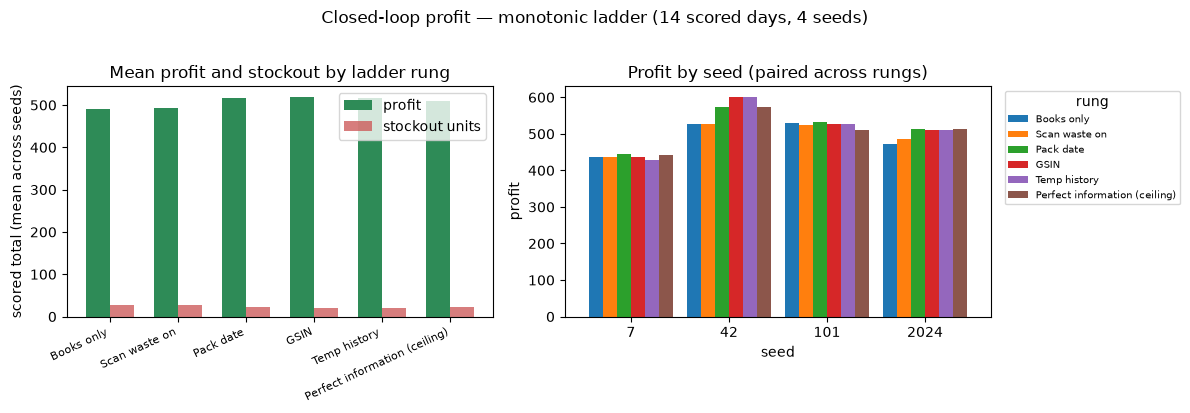

In [5]:
_PROFIT_ORDER = LADDER_DISPLAY_ORDER + ["Perfect information (ceiling)"]
plot_profit = (
    profit_df.groupby("data_package")[["profit", "waste", "stockout"]]
    .mean()
    .reindex([label for label in _PROFIT_ORDER if label in profit_df["data_package"].values])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = range(len(plot_profit))
width = 0.35
axes[0].bar([i - width / 2 for i in x], plot_profit["profit"], width=width, label="profit", color="seagreen")
axes[0].bar([i + width / 2 for i in x], plot_profit["stockout"], width=width, label="stockout units", color="indianred", alpha=0.8)
axes[0].set_xticks(list(x), plot_profit["data_package"], rotation=25, ha="right", fontsize=8)
axes[0].set_ylabel("scored total (mean across seeds)")
axes[0].set_title("Mean profit and stockout by ladder rung")
axes[0].legend()

seed_pivot = profit_df.pivot_table(index="seed", columns="data_package", values="profit", aggfunc="mean")
seed_pivot = seed_pivot.reindex(columns=[c for c in _PROFIT_ORDER if c in seed_pivot.columns])
seed_pivot.plot.bar(ax=axes[1], width=0.85)
axes[1].set_title("Profit by seed (paired across rungs)")
axes[1].set_ylabel("profit")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="rung", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.suptitle(f"Closed-loop profit — monotonic ladder ({N_SCORE} scored days, {len(PROFIT_SEEDS)} seeds)", y=1.02)
fig.tight_layout()
_fig_path = FIG_DIR / "nb17_profit_by_package.png"
fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
print(f"saved {_fig_path.relative_to(REPO_ROOT)}")
plt.show()


### Part 2 — Results summary

Re-run this cell after execution; numbers below are written by the comparison cell.

## How Part 1 and Part 2 fit together

The two parts measure **different things on purpose**:

- **Part 1** freezes reality and scores belief error only (8 gsin shards; means over two seeds per regime).
- **Part 2** lets beliefs drive orders and scores dollars (5 monotonic ladder rungs + oracle, 4 seeds, 14 scored days).

**Monotonicity check:** compare each rung to the previous on `filter_agg` (belief MAE) and
`profit_summary` (mean profit). Strict improvement is not guaranteed — especially F3 vs F2
where the preset API swaps pack date for temperature history.

**Caveats:** two seeds per regime in Part 1, four profit seeds, damped_sw controller. See
`experiments/modal/PRELIM_SCALING.md` for the next budget tier.

In [6]:
# Monotonicity diagnostics (belief + profit per rung)
belief_ladder = (
    filter_agg.groupby("data_package")[["count_mae", "store_mean_f_mae"]]
    .mean()
    .reindex(LADDER_DISPLAY_ORDER)
)
profit_ladder = (
    profit_df.groupby("data_package")[["profit", "waste", "stockout"]]
    .mean()
    .reindex(LADDER_DISPLAY_ORDER)
)

def _mono_flags(series: pd.Series, *, lower_better: bool) -> pd.Series:
    diffs = series.diff()
    if lower_better:
        return diffs <= 0
    return diffs >= 0

belief_ladder["count_mae_monotone"] = _mono_flags(belief_ladder["count_mae"], lower_better=True)
belief_ladder["fresh_mae_monotone"] = _mono_flags(belief_ladder["store_mean_f_mae"], lower_better=True)
profit_ladder["profit_monotone"] = _mono_flags(profit_ladder["profit"], lower_better=False)

print("=== Belief MAE by rung (lower is better) ===")
display(belief_ladder)
print("\n=== Profit by rung ===")
display(profit_ladder)

# Persist for cross-PR comparison
_out = REPO_ROOT / "figures" / "nb17" / "monotonic_ladder_summary.csv"
pd.concat(
    [
        belief_ladder.add_prefix("belief_"),
        profit_ladder.add_prefix("profit_"),
    ],
    axis=1,
).to_csv(_out)
print(f"saved {_out.relative_to(REPO_ROOT)}")


=== Belief MAE by rung (lower is better) ===


,count_mae,store_mean_f_mae,count_mae_monotone,fresh_mae_monotone
data_package,,,,
Books only,5.338275,0.064732,False,False
Scan waste on,0.014750,0.063988,True,True
Pack date,0.111400,0.025358,False,True
GSIN,0.012088,0.021698,True,True
Temp history,0.006638,0.012147,True,True



=== Profit by rung ===


,profit,waste,stockout,profit_monotone
data_package,,,,
Books only,491.500,11.50,26.75,False
Scan waste on,492.875,9.75,27.00,True
Pack date,515.750,9.50,22.50,True
GSIN,518.375,12.75,21.00,True
Temp history,516.500,14.00,21.00,False


saved figures/nb17/monotonic_ladder_summary.csv
